In [1]:
import pickle

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
import os
import argparse

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import sys

sys.path.append("../src")
sys.path.append("../config")

from data_process import load_wls_adress_AddDomain
from process_SHAC import load_process_SHAC
from process_CD import load_cd
from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from sampling_numbers import HateSpeech_DICT, SHAC_DICT, CD_DICT

from tqdm.auto import tqdm
import numpy as np
import pandas as pd

import torch
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)
from scipy.special import softmax
from accelerate.utils import load_and_quantize_model
import itertools

In [5]:
from utils import number_split, create_mix, appendMetrics


In [6]:
from sklearn.manifold import TSNE

In [7]:
def do_Inference_HiddenSpece(txts):
        df_in = tokenizer(
            list(txts),
            return_tensors="pt",
            max_length=globalconfig.max_seq_length,
            padding="max_length",
            truncation=True,
        )

        ret_ls = []
        lst = list(range(len(df_in["input_ids"])))
        n = args.batch_size
        idx_ls = [lst[i : i + n] for i in range(len(lst)) if i % n == 0]

        model.eval()
        with torch.no_grad():
            for idx in tqdm(idx_ls, file=open(log_f, "w")):
                ret_output = model.roberta(
                    input_ids=df_in["input_ids"][idx].to(globalconfig.device),
                    attention_mask=df_in["attention_mask"][idx].to(globalconfig.device),
                    output_hidden_states=True,
                    return_dict=True,
                    output_attentions=True,
                )

                ret_ls.append(ret_output[0][:,0,:].detach().cpu().numpy())



        return np.concatenate(ret_ls)

# Load Data & Model

In [4]:
### Main
# dataset_name = "CD"
# dataset_name = "HateSpeech"

# # isample = 566
# isample = 6621


dataset_name = "SHAC"


isample = 1152
# isample = 11063


# methodUsed = "noaug"
# methodUsed = "MMD"
# methodUsed = "GDRO"
methodUsed = "GradientReverse"

if dataset_name == "SHAC" and methodUsed == "MMD":
    ep = 6
else:
    ep = 3

if dataset_name == "SHAC":
    n_test_eval = 800
else:
    n_test_eval = 1000
    
if methodUsed == "noaug":
    weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}-FullFT-noaug/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
else:
    weightsEdited=f"/bime-munin/xiruod/{methodUsed}/roberta-base_{dataset_name}/n200/set-{isample}-epoch{ep}/pytorch_model.bin"


log_f = "../log/test.log"

In [5]:
class Args:
    model_name='roberta-base'
    weightsEdited = weightsEdited
    output_dir="~/Downloads/tmp"
    gpu="3"
    device="cuda:0"
    batch_size=8
    dataset=dataset_name

In [6]:
args = Args()

In [8]:
class train_config:
    def __init__(self):
        self.quantization: bool = False


# tmp = [x for x in args.weightsEdited.split("/") if "set-" in x]
# # of form like set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added.pth
# name_pre = tmp[0].split(".pth")[0]
# # 7, 13, 70
# outdir = args.output_dir
# name_general = f"runningInferenceOnly"
# log_f = f"../log/{name_general}.log"

# os.makedirs(outdir, exist_ok=True)

globalconfig = train_config()
globalconfig.model_name = args.model_name
globalconfig.max_seq_length = 512
globalconfig.device = args.device

##### Tokenizer
tokenizer = AutoTokenizer.from_pretrained(globalconfig.model_name, use_fast=False)

# if args.cpuOps:
#     load_device = "cpu"
#     load_state_device = "cpu"
# else:
#     load_device = globalconfig.device
#     load_state_device = globalconfig.device
load_device = globalconfig.device
load_state_device = globalconfig.device

##### Load Model and  Update using Edited Weights
model = AutoModelForSequenceClassification.from_pretrained(
    globalconfig.model_name,
    use_safetensors=False,
)

# this step cannot be ignored here...

if methodUsed == "GradientReverse":
    tmp = torch.load(
        args.weightsEdited,
        map_location="cpu",
        # map_location=lambda storage, loc: storage,
    )

    key_ToRemove = ["classifierDomain.dense.weight", 
                    "classifierDomain.dense.bias", 
                    "classifierDomain.out_proj.weight", 
                    "classifierDomain.out_proj.bias",
                   ]

    for _ in key_ToRemove:
        del tmp[_]
else:
    tmp = torch.load(
        args.weightsEdited,
        map_location="cpu",
        # map_location=lambda storage, loc: storage,
    )
    

# this step cannot be ignored here...
model.load_state_dict(
    tmp
)




model = model.to(globalconfig.device)

print("###  Finished Loading...")

# if args.quantization:
#     bnb_quantization_config = BnbQuantizationConfig(
#         load_in_8bit=True, llm_int8_threshold=6
#     )
#     model = load_and_quantize_model(
#         model,
#         weights_location=args.weightsEdited,
#         bnb_quantization_config=bnb_quantization_config,
#         device_map=load_device,
#     )

# print("###  Finished Quantization...")

/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###  Finished Loading...


In [9]:
if dataset_name == "CD":
    df_all = load_cd()
    df_avh = df_all["avh"]
    df_r56 = df_all["r56"]

    txt_col = "text"

    z_Categories = ["avh","r56"] 

    domain_col = "dfSource"
    df_split_label = "label_binary"
    y_Categories = [0, 1]

    labels = ["Negative", "Positive"]
    
elif dataset_name == "HateSpeech":
    df_dynGen = load_HateSpeech_dynGen()
    df_wsf = load_HateSpeech_wsf()

    txt_col = "text"
    
    z_Categories = ["dynGen","wsf"] 
    df_split_label = "label_binary"
    y_Categories = [0, 1]

    domain_col = "dfSource"
    labels = ["Negative", "Positive"]

elif dataset_name == "SHAC":
#     df_dynGen = load_HateSpeech_dynGen()
#     df_wsf = load_HateSpeech_wsf()

    df_shac = load_process_SHAC(replaceNA="all")
    domain_col = "location"
    label = "Drug"

    df_shac = load_process_SHAC(replaceNA="all")
    df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x[label] else 0, axis=1)
    df_shac["dfSource"] = df_shac[domain_col]
    
    df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
    df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)
        
    txt_col = "text"
    
    df_split_label = "label_binary"
    y_Categories = [0, 1]
    
    z_Categories = ["uw", "mimic"] 

    labels = ["Negative", "Positive"]

# Select a balance set

In [14]:
pick_C = isample
n_test = 200
label = "label_binary"

if dataset_name == "CD":
    df0 = df_avh
    df1 = df_r56
    c = CD_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "HateSpeech":
    df0 = df_dynGen
    df1 = df_wsf

    c = HateSpeech_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "SHAC":
    df0 = df_shac_uw
    df1 = df_shac_mimic

    c = SHAC_DICT[f"c_n{n_test}_{pick_C}"]



dfs_used = create_mix(
    df0=df0,
    df1=df1,
    target=label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


balanced_setting = number_split(
        p_pos_train_z0=0.3,
        p_pos_train_z1=0.3,
        p_mix_z1=0.5,
        alpha_test=1,
        train_test_ratio=1,
        n_test=n_test_eval,
        verbose=False,
    )

In [15]:
balanced_setting

{'n_train': 800,
 'n_test': 800,
 'n_z0_pos_train': 120,
 'n_z0_neg_train': 280,
 'n_z0_pos_test': 120,
 'n_z0_neg_test': 280,
 'n_z1_pos_train': 120,
 'n_z1_neg_train': 280,
 'n_z1_pos_test': 120,
 'n_z1_neg_test': 280,
 'mix_param_dict': {'p_pos_train_z0': 0.3,
  'p_pos_train_z1': 0.3,
  'p_pos_train': 0.3,
  'p_pos_test': 0.3,
  'p_mix_z0': 0.5,
  'p_mix_z1': 0.5,
  'alpha_train': 1.0,
  'alpha_test': 1,
  'p_pos_test_z0': 0.3,
  'p_pos_test_z1': 0.3,
  'C_y': 0.3,
  'C_z': 0.5,
  'C_y_test': 0.3}}

In [16]:
c = balanced_setting.copy()
c["n_train"] = 0
c["n_z0_pos_train"] = 1
c["n_z0_neg_train"] = 1
c["n_z1_pos_train"] = 1
c["n_z1_neg_train"] = 1
c["mix_param_dict"]["p_pos_train_z0"] = 0
c["mix_param_dict"]["p_pos_train_z1"] = 0
c["mix_param_dict"]["p_pos_train"] = 0
c["mix_param_dict"]["alpha_train"] = 0

# create train/test split according to stats
dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

In [17]:
dfs['test'].groupby("dfSource")[label].sum()

dfSource
mimic    120
uw       120
Name: label_binary, dtype: int64

In [18]:
dfs['test'].groupby("dfSource").size()

dfSource
mimic    400
uw       400
dtype: int64

In [19]:
dfs['test']

,id,Drug,Alcohol,Tobacco,SubstanceAgg,set,location,text,label_binary,dfSource
0,3829,True,True,True,True,train,uw,"HABITS: Drinks 2 liquer drinks a week, last d...",1,uw
1,3652,True,True,False,True,train,uw,HABITS: Tobacco Use: never Alcohol Use: soc...,1,uw
2,1582,True,True,False,True,test,uw,"Social History: Rare alcohol, no tobacco, smok...",1,uw
3,3420,True,True,True,True,train,uw,HABITS: Tobacco Use: 1ppd x 20 years pending ...,1,uw
4,1565,True,False,True,True,test,uw,SOCIAL HISTORY: Currently homeless Lives in [...,1,uw
...,...,...,...,...,...,...,...,...,...,...
795,0822,False,False,True,True,train,mimic,Social History: Pt is homeless. Denies IVDA. S...,0,mimic
796,0727,False,True,True,True,dev,mimic,Social History: Lives in [**Location (un) 8973...,0,mimic
797,4751,False,False,True,True,train,mimic,Social History: tobacco: 50-60 pack-years down...,0,mimic
798,0876,False,False,True,True,train,mimic,SOCIAL HISTORY: Lives independently. Retired...,0,mimic


# Do Inference

In [21]:
array_hidden = do_Inference_HiddenSpece(dfs["test"][txt_col])

  0%|          | 0/100 [00:00<?, ?it/s]

In [22]:
array_hidden.shape

(800, 768)

# t-SNE

In [23]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [25]:
X_embedded = TSNE(n_components=2, learning_rate='auto', perplexity=30).fit_transform(array_hidden)

In [26]:
print(methodUsed)
print(isample)

GradientReverse
1152


In [27]:
# df = pd.DataFrame({"d1":X_embedded[:,0],
#                    "d2":X_embedded[:,1],
#                    "domain": dfs["test"][domain_col],
#                    "target": dfs["test"][df_split_label]
                   
#                   })

# sns.scatterplot(data=df, x="d1", y="d2", hue='domain', style="target", alpha=0.6)

In [28]:
z_Categories

['uw', 'mimic']

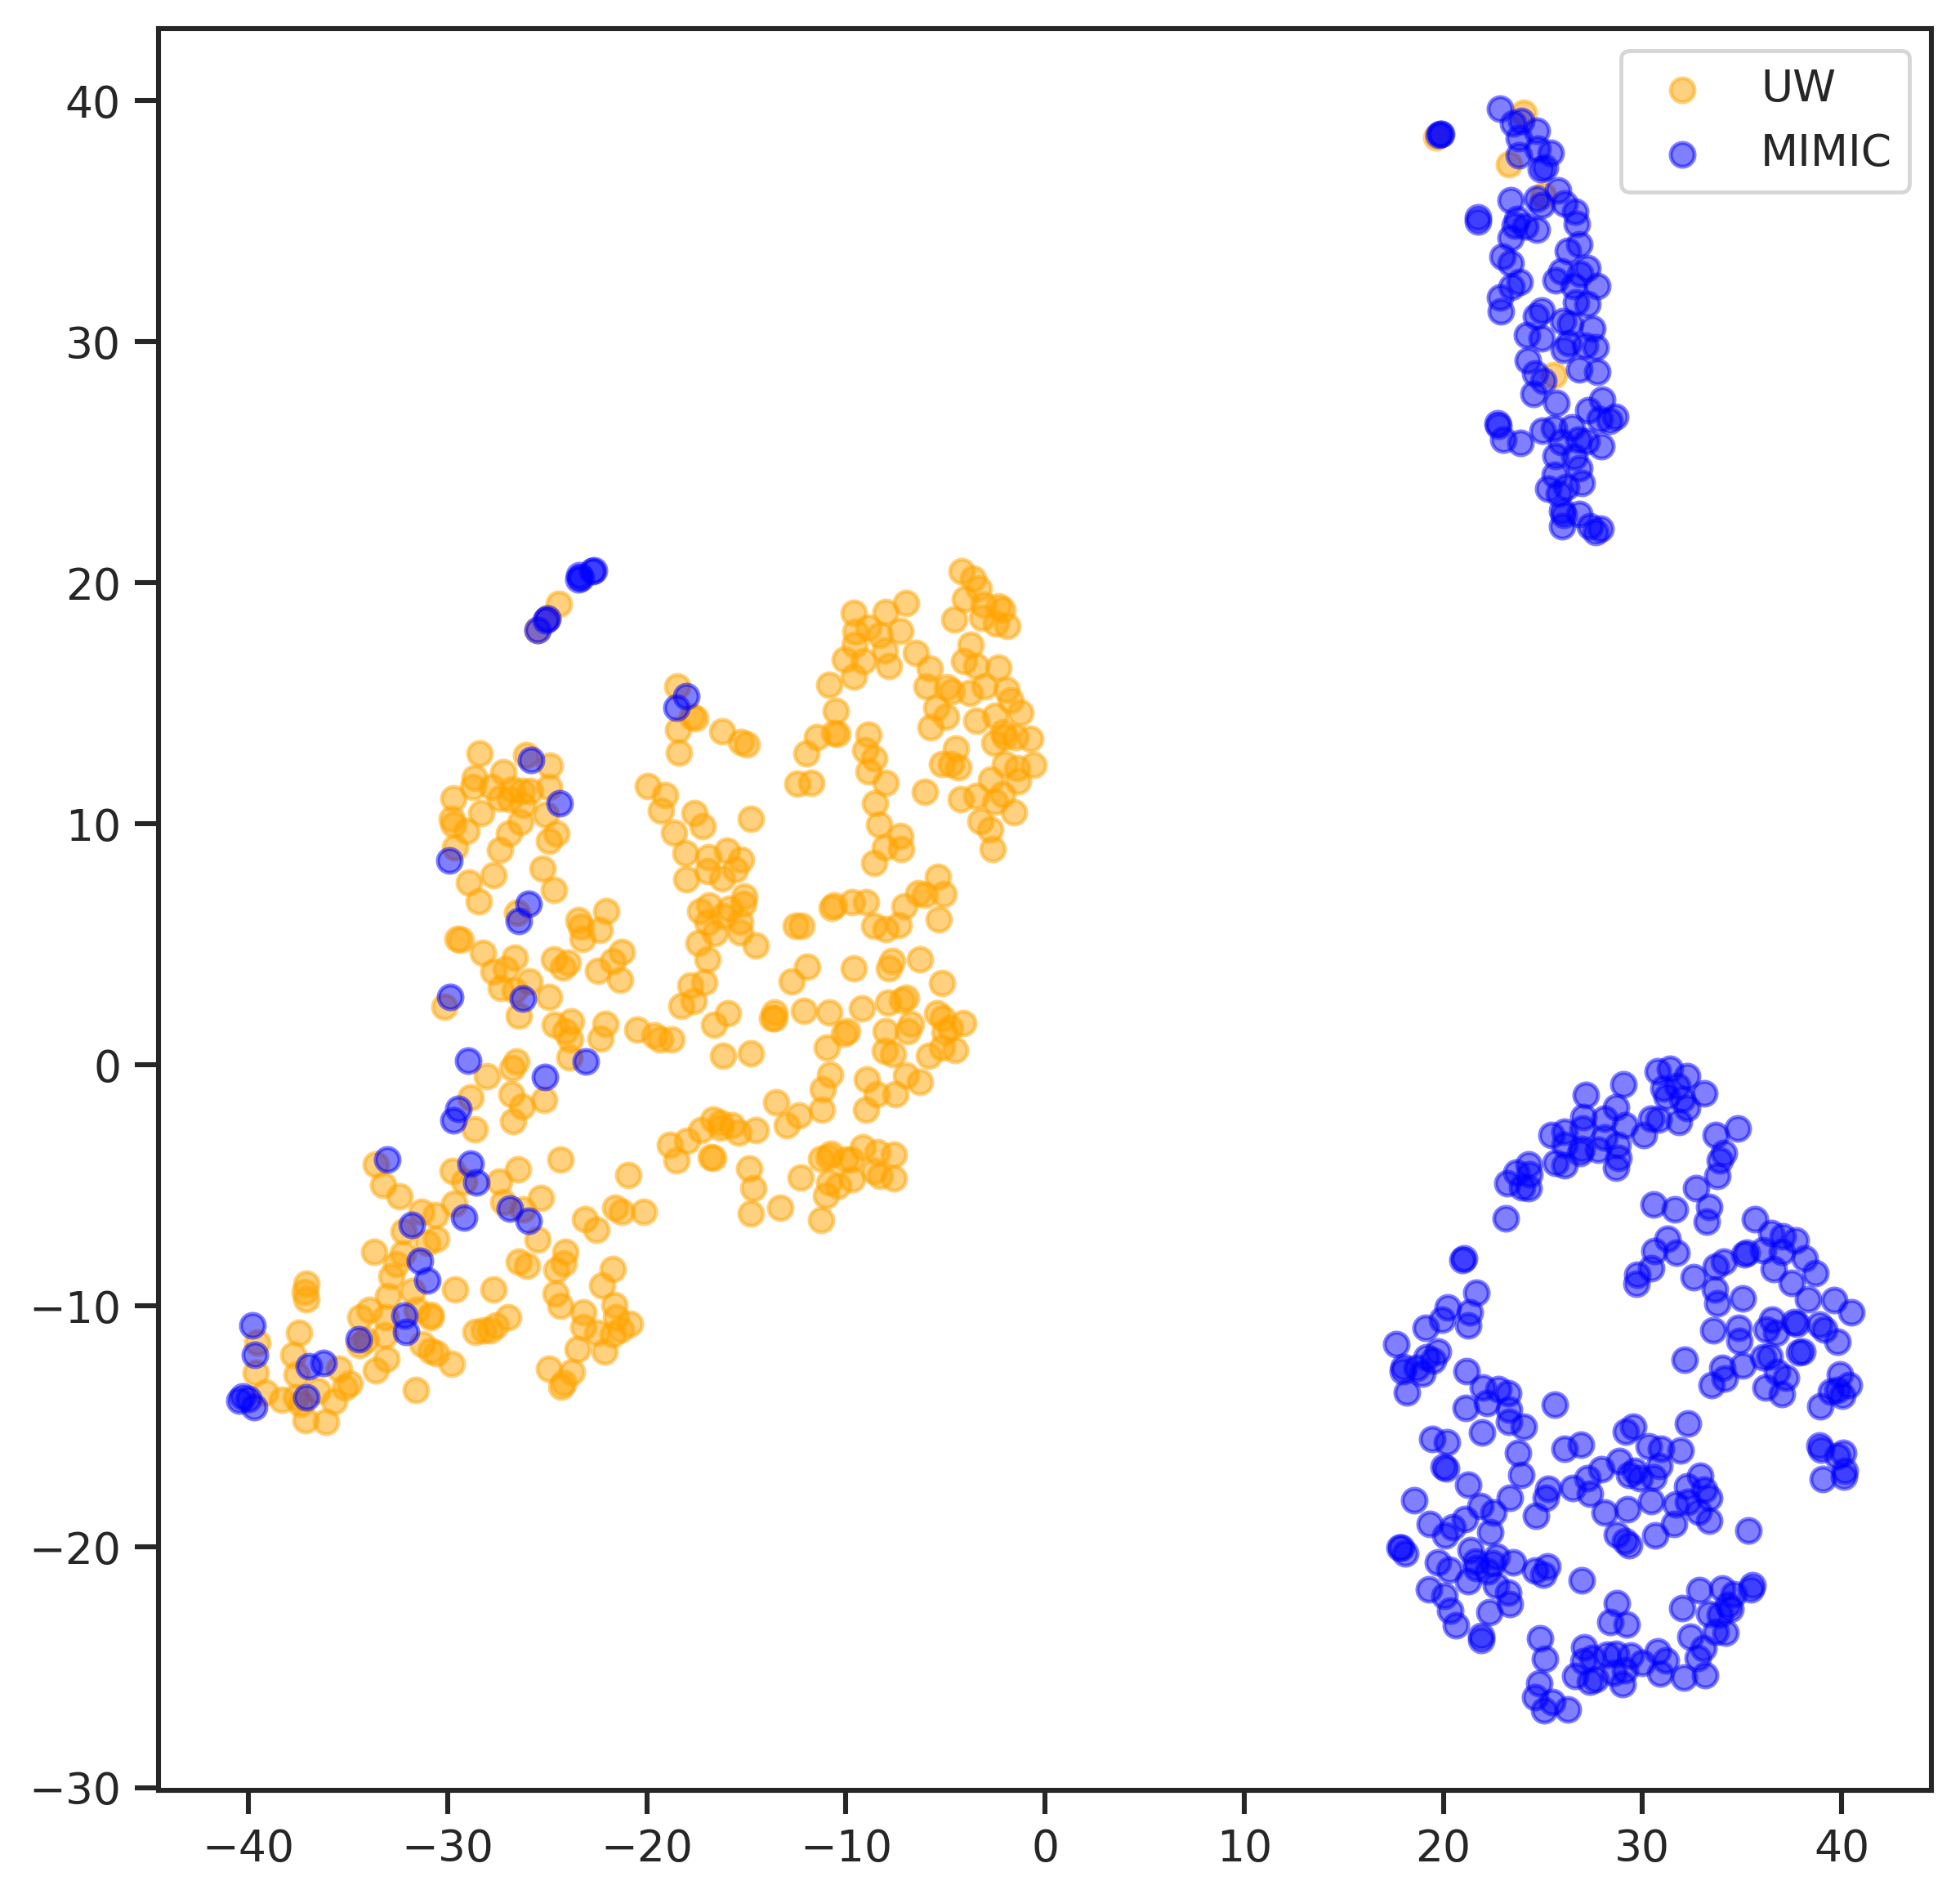

In [29]:
fig, ax = plt.subplots(1,1, figsize=(8,8), sharey=True)

c_lst = ['orange', 'blue']


z_DICT = {"avh":"AVH",
          "r56": "TM",
          "wsf": "WSF",
          "dynGen": "dynGEN",
          "uw": "UW",
          "mimic":"MIMIC",
         }

for _idx, (_z,_y) in enumerate(zip(z_Categories, y_Categories)):
    
    _label = z_DICT[_z]        
        
    _select = (dfs["test"][domain_col] == _z)
    ax.scatter(X_embedded[_select,0], X_embedded[_select,1], alpha=.5, c=c_lst[_idx],  label=_label)

ax.legend()

plt.show()

# Plot All

In [8]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [9]:
title_DICT = {"noaug":"baseline", "MMD":"MMD", "GDRO":"GDRO", "GradientReverse":"DANN"}

In [10]:
np.random.seed(184) # for t-SNE

savefig = True
# savefig = True



for dtlist, setls in itertools.product(['CD','HateSpeech'], [566, 6621]):
    plt.clf()
    fig, axes = plt.subplots(2,2, figsize=(16,16), sharey=False, sharex=False)

    axes = axes.ravel()

    for _idxOverall,(dataset_name, isample, methodUsed) in enumerate(itertools.product([dtlist], [setls], ["noaug",  "GradientReverse", "MMD", "GDRO",])):

        if dataset_name == "SHAC" and methodUsed == "MMD":
            ep = 6
        else:
            ep = 3

        if dataset_name == "SHAC":
            n_test_eval = 800
        else:
            n_test_eval = 1000

        outname = f"../output/MMD_GDRO_GradReverse_Figs/RoBERTa/fig-tSNE-{dataset_name}-set_{isample}-balencedSet.png"


        log_f = "../log/test.log"


        class Args:
            model_name='roberta-base'
            if methodUsed == "noaug":
                weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}-FullFT-noaug/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
            else:
                weightsEdited=f"/bime-munin/xiruod/{methodUsed}/roberta-base_{dataset_name}/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
            output_dir="~/Downloads/tmp"
            gpu="3"
            device="cuda:0"
            batch_size=8
            dataset=dataset_name

        args = Args()

        class train_config:
            def __init__(self):
                self.quantization: bool = False


        globalconfig = train_config()
        globalconfig.model_name = args.model_name
        globalconfig.max_seq_length = 512
        globalconfig.device = args.device


        load_device = globalconfig.device
        load_state_device = globalconfig.device

        ##### Tokenizer
        tokenizer = AutoTokenizer.from_pretrained('roberta-base', use_fast=False)



        ##### Load Model and  Update using Edited Weights
        model = AutoModelForSequenceClassification.from_pretrained(
            globalconfig.model_name,
            use_safetensors=False,
        )

        # this step cannot be ignored here...

        if methodUsed == "GradientReverse":
            tmp = torch.load(
                args.weightsEdited,
                map_location="cpu",
                # map_location=lambda storage, loc: storage,
            )

            key_ToRemove = ["classifierDomain.dense.weight", 
                            "classifierDomain.dense.bias", 
                            "classifierDomain.out_proj.weight", 
                            "classifierDomain.out_proj.bias",
                           ]

            for _ in key_ToRemove:
                del tmp[_]
        else:
            tmp = torch.load(
                args.weightsEdited,
                map_location="cpu",
                # map_location=lambda storage, loc: storage,
            )


        # this step cannot be ignored here...
        model.load_state_dict(
            tmp
        )




        model = model.to(globalconfig.device)

        print("###  Finished Loading...")



        if dataset_name == "CD":
            df_all = load_cd()
            df_avh = df_all["avh"]
            df_r56 = df_all["r56"]

            txt_col = "text"

            z_Categories = ["avh","r56"] 

            domain_col = "dfSource"
            df_split_label = "label_binary"
            y_Categories = [0, 1]

            labels = ["Negative", "Positive"]

        elif dataset_name == "HateSpeech":
            df_dynGen = load_HateSpeech_dynGen()
            df_wsf = load_HateSpeech_wsf()

            txt_col = "text"

            z_Categories = ["dynGen","wsf"] 
            df_split_label = "label_binary"
            y_Categories = [0, 1]

            domain_col = "dfSource"
            labels = ["Negative", "Positive"]

        elif dataset_name == "SHAC":
        #     df_dynGen = load_HateSpeech_dynGen()
        #     df_wsf = load_HateSpeech_wsf()

            df_shac = load_process_SHAC(replaceNA="all")
            domain_col = "location"
            label = "Drug"

            df_shac = load_process_SHAC(replaceNA="all")
            df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x[label] else 0, axis=1)
            df_shac["dfSource"] = df_shac[domain_col]

            df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
            df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)

            txt_col = "text"

            df_split_label = "label_binary"
            y_Categories = [0, 1]

            z_Categories = ["uw", "mimic"] 

            labels = ["Negative", "Positive"]


        pick_C = isample
        n_test = 200
        label = "label_binary"

        if dataset_name == "CD":
            df0 = df_avh
            df1 = df_r56
            c = CD_DICT[f"c_n{n_test}_{pick_C}"]

        elif dataset_name == "HateSpeech":
            df0 = df_dynGen
            df1 = df_wsf

            c = HateSpeech_DICT[f"c_n{n_test}_{pick_C}"]

        elif dataset_name == "SHAC":
            df0 = df_shac_uw
            df1 = df_shac_mimic

            c = SHAC_DICT[f"c_n{n_test}_{pick_C}"]



        dfs_used = create_mix(
            df0=df0,
            df1=df1,
            target=label,
            setting=c,
            sample=False,
            # seed=random.randint(0,1000),
            seed=222,
        )

        df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
        df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


        df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
        df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


        balanced_setting = number_split(
                p_pos_train_z0=0.3,
                p_pos_train_z1=0.3,
                p_mix_z1=0.5,
                alpha_test=1,
                train_test_ratio=1,
                n_test=n_test_eval,
                verbose=False,
            )

        c = balanced_setting.copy()
        c["n_train"] = 0
        c["n_z0_pos_train"] = 1
        c["n_z0_neg_train"] = 1
        c["n_z1_pos_train"] = 1
        c["n_z1_neg_train"] = 1
        c["mix_param_dict"]["p_pos_train_z0"] = 0
        c["mix_param_dict"]["p_pos_train_z1"] = 0
        c["mix_param_dict"]["p_pos_train"] = 0
        c["mix_param_dict"]["alpha_train"] = 0

        # create train/test split according to stats
        dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

        array_hidden = do_Inference_HiddenSpece(dfs["test"][txt_col])

        print(array_hidden.shape)

        X_embedded = TSNE(n_components=2, learning_rate='auto', perplexity=30).fit_transform(array_hidden)

        print(methodUsed)
        print(isample)




        c_lst = ['orange', 'blue']


        z_DICT = {"avh":"AVH",
                  "r56": "TM",
                  "wsf": "WSF",
                  "dynGen": "dynGEN",
                  "uw": "UW",
                  "mimic":"MIMIC",
                 }

        for _idx, (_z,_y) in enumerate(zip(z_Categories, y_Categories)):

            _label = z_DICT[_z]        

            _select = (dfs["test"][domain_col] == _z)
            axes[_idxOverall].scatter(X_embedded[_select,0], X_embedded[_select,1], alpha=.5, c=c_lst[_idx],  label=_label)

        axes[_idxOverall].legend()

        axes[_idxOverall].set_title(title_DICT[methodUsed], #fontweight="bold", 
                                    size=20) 

        # axes[_idxOverall].title.set_text(r"$\bf{" + title_DICT[methodUsed]+ "}$")
        # axes[_idxOverall].tick_params(axis='x', labelsize=6)
        # axes[_idxOverall].tick_params(axis='y', labelsize=6)
        # axes[_idxOverall].set_xticks([])
        # axes[_idxOverall].set_yticks([]) 


    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()
        
    plt.clf()




/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###  Finished Loading...


  0%|          | 0/125 [00:00<?, ?it/s]

(1000, 768)
noaug
566


/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

<Figure size 2240x1680 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>